# Laboratorio 4.2 - Ejercicio 1: Preparación de datos para Machine Learning

Este notebook construye un conjunto tabular a partir de los rasters de Sentinel-2 de los lagos Atitlán y Amatitlán. Cada fila final corresponde al centro de un píxel geográfico válido. Se cubren los incisos **1.1 a 1.6**: integración de capas, limpieza, resumen del conjunto, análisis exploratorio y justificación de decisiones.

Los rasters de bandas provienen de Sentinel-2 L1C, tienen 20 m de resolución y están en WGS 84 / UTM zona 15N (EPSG:32615). Los rasters de índices producidos en la Parte I están en WGS 84 (EPSG:4326) e incluyen las capas `cyanobacteria_chla`, `ndvi`, `ndwi` y `valid_mask`. Por ello, las bandas se alinean a la grilla de índices antes de crear las observaciones.

## 1. Configuración e inventario de datos

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import Resampling, reproject
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# Permite ejecutar el notebook desde la raíz del repositorio o desde un subdirectorio.
ROOT = Path.cwd()
if not (ROOT / "datos_lagos").exists() and (ROOT.parent / "datos_lagos").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "datos_lagos"
OUTPUT_DIR = ROOT / "resultados" / "ejercicio_1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BANDS = ["B03", "B04", "B05", "B08"]
INDEX_COLUMNS = ["cyanobacteria_chla", "ndvi", "ndwi"]
PATTERN = re.compile(r"(?P<lake>atitlan|amatitlan)_(?P<date>\d{4}-\d{2}-\d{2})_indices\.tif$")

index_files = sorted(DATA_DIR.rglob("*_indices.tif"))
records = []
for path in index_files:
    match = PATTERN.match(path.name)
    if match:
        record = {"lago": match["lake"], "fecha": pd.Timestamp(match["date"]), "indices": path}
        record.update({band: path.with_name(path.name.replace("_indices.tif", f"_{band}.tif")) for band in BANDS})
        records.append(record)

inventory = pd.DataFrame(records)
if inventory.empty:
    raise FileNotFoundError(f"No se encontraron rasters de índices en {DATA_DIR}")

missing_files = [str(row[band]) for _, row in inventory.iterrows() for band in BANDS if not row[band].exists()]
if missing_files:
    raise FileNotFoundError("Faltan rasters de bandas:\n" + "\n".join(missing_files))

print(f"Escenas encontradas: {len(inventory)}")
display(inventory.groupby("lago", observed=True).agg(escenas=("fecha", "size"), fecha_inicial=("fecha", "min"), fecha_final=("fecha", "max")))
display(inventory[["lago", "fecha"]])

Escenas encontradas: 22


,escenas,fecha_inicial,fecha_final
lago,,,
amatitlan,11,2025-01-28,2026-06-19
atitlan,11,2025-01-18,2026-07-22


,lago,fecha
0,amatitlan,2025-01-28
1,amatitlan,2025-04-15
2,amatitlan,2025-04-28
3,amatitlan,2025-11-24
4,amatitlan,2026-01-08
5,amatitlan,2026-02-02
6,amatitlan,2026-02-07
7,amatitlan,2026-03-29
8,amatitlan,2026-04-13
9,amatitlan,2026-04-28


### Comprobación de metadatos

Antes de combinar las capas se verifican dimensiones, CRS, resolución, nombres de bandas y valores NoData. Esta inspección evita asumir que los rasters de bandas e índices tienen la misma grilla.

In [2]:
metadata_rows = []
for _, scene in inventory.iterrows():
    for layer in ["indices", *BANDS]:
        with rasterio.open(scene[layer]) as src:
            metadata_rows.append({
                "lago": scene["lago"],
                "fecha": scene["fecha"],
                "capa": layer,
                "crs": str(src.crs),
                "filas": src.height,
                "columnas": src.width,
                "res_x": abs(src.res[0]),
                "res_y": abs(src.res[1]),
                "nodata": src.nodata,
                "bandas_raster": src.count,
                "descripciones": ", ".join(description or "" for description in src.descriptions),
            })

metadata = pd.DataFrame(metadata_rows)
display(metadata.groupby(["lago", "capa", "crs", "filas", "columnas", "bandas_raster"], dropna=False).size().rename("n_escenas").reset_index())

,lago,capa,crs,filas,columnas,bandas_raster,n_escenas
0,amatitlan,B03,EPSG:32615,459,681,1,11
1,amatitlan,B04,EPSG:32615,459,681,1,11
2,amatitlan,B05,EPSG:32615,459,681,1,11
3,amatitlan,B08,EPSG:32615,459,681,1,11
4,amatitlan,indices,EPSG:4326,458,670,4,11
5,atitlan,B03,EPSG:32615,876,1380,1,11
6,atitlan,B04,EPSG:32615,876,1380,1,11
7,atitlan,B05,EPSG:32615,876,1380,1,11
8,atitlan,B08,EPSG:32615,876,1380,1,11
9,atitlan,indices,EPSG:4326,875,1365,4,11


## 2. Construcción y limpieza del conjunto (1.1-1.3)

Se aplican las siguientes reglas de calidad:

1. `valid_mask == 1`: se conserva únicamente la máscara válida producida en la Parte I, que delimita el agua del lago y excluye observaciones no aptas, incluidas nubes detectadas durante ese procesamiento.
2. Todos los índices y bandas deben ser finitos; así se eliminan NoData y fallos de reproyección.
3. `NDVI` y `NDWI` deben pertenecer a su intervalo matemático `[-1, 1]`.
4. Los números digitales de las bandas deben estar en `(0, 20000]`. El límite superior es deliberadamente tolerante respecto al factor de cuantificación 10,000 de Sentinel-2 para no eliminar reflectancias brillantes válidas; se excluyen valores negativos o extremos de interpolación.
5. Las bandas se dividen entre 10,000 para expresarlas como reflectancia. La reproyección bilineal es apropiada para variables espectrales continuas.

No se elimina un valor negativo de `cyanobacteria_chla` solamente por su signo: es una salida numérica posible del algoritmo espectral y representa evidencia baja, no un NoData. En el Ejercicio 2 se establecerá y justificará el umbral ambiental para convertir este índice en respuesta binaria.

In [3]:
def read_scene(scene):
    # Alinea una escena, aplica controles de calidad y devuelve píxeles válidos.
    with rasterio.open(scene["indices"]) as idx_src:
        descriptions = list(idx_src.descriptions)
        required = [*INDEX_COLUMNS, "valid_mask"]
        if any(name not in descriptions for name in required):
            raise ValueError(f"{scene['indices'].name} no contiene las capas requeridas: {required}")

        arrays = {
            name: idx_src.read(descriptions.index(name) + 1).astype("float32")
            for name in required
        }
        destination_shape = (idx_src.height, idx_src.width)
        destination_transform = idx_src.transform
        destination_crs = idx_src.crs

        spectral = {}
        for band in BANDS:
            with rasterio.open(scene[band]) as band_src:
                destination = np.full(destination_shape, np.nan, dtype="float32")
                reproject(
                    source=rasterio.band(band_src, 1),
                    destination=destination,
                    src_transform=band_src.transform,
                    src_crs=band_src.crs,
                    src_nodata=band_src.nodata,
                    dst_transform=destination_transform,
                    dst_crs=destination_crs,
                    dst_nodata=np.nan,
                    resampling=Resampling.bilinear,
                )
                spectral[band] = destination

        base_mask = arrays["valid_mask"] == 1
        finite_indices = np.logical_and.reduce([np.isfinite(arrays[name]) for name in INDEX_COLUMNS])
        finite_bands = np.logical_and.reduce([np.isfinite(spectral[band]) for band in BANDS])
        physical_indices = (
            arrays["ndvi"].between(-1, 1) if isinstance(arrays["ndvi"], pd.Series)
            else ((arrays["ndvi"] >= -1) & (arrays["ndvi"] <= 1))
        ) & (arrays["ndwi"] >= -1) & (arrays["ndwi"] <= 1)
        physical_bands = np.logical_and.reduce([
            (spectral[band] > 0) & (spectral[band] <= 20_000) for band in BANDS
        ])
        valid = base_mask & finite_indices & finite_bands & physical_indices & physical_bands

        rows, cols = np.where(valid)
        xs, ys = rasterio.transform.xy(destination_transform, rows, cols, offset="center")

        frame = pd.DataFrame({
            "longitud": np.asarray(xs, dtype="float64"),
            "latitud": np.asarray(ys, dtype="float64"),
            "fecha": pd.Timestamp(scene["fecha"]),
            "lago": scene["lago"],
            **{band: spectral[band][valid] / 10_000 for band in BANDS},
            **{name: arrays[name][valid] for name in INDEX_COLUMNS},
        })

        quality = {
            "lago": scene["lago"],
            "fecha": pd.Timestamp(scene["fecha"]),
            "pixeles_raster": int(valid.size),
            "mascara_parte_i": int(base_mask.sum()),
            "indices_finitos": int((base_mask & finite_indices).sum()),
            "bandas_finitas": int((base_mask & finite_indices & finite_bands).sum()),
            "observaciones_finales": int(valid.sum()),
        }
        quality["eliminadas_control_adicional"] = quality["mascara_parte_i"] - quality["observaciones_finales"]
        return frame, quality


frames = []
quality_rows = []
for _, scene in inventory.iterrows():
    frame, quality = read_scene(scene)
    frames.append(frame)
    quality_rows.append(quality)

data = pd.concat(frames, ignore_index=True)
quality_report = pd.DataFrame(quality_rows).sort_values(["lago", "fecha"]).reset_index(drop=True)

# Tipos compactos y semánticos para el conjunto final.
data["lago"] = data["lago"].astype("category")
for column in [*BANDS, *INDEX_COLUMNS]:
    data[column] = data[column].astype("float32")

assert not data.empty, "La limpieza eliminó todas las observaciones"
assert data[["longitud", "latitud", *BANDS, *INDEX_COLUMNS]].notna().all().all()
assert data["ndvi"].between(-1, 1).all() and data["ndwi"].between(-1, 1).all()

display(quality_report)
print(f"Observaciones válidas construidas: {len(data):,}")

,lago,fecha,pixeles_raster,mascara_parte_i,indices_finitos,bandas_finitas,observaciones_finales,eliminadas_control_adicional
0,amatitlan,2025-01-28,306860,36896,36896,36896,36896,0
1,amatitlan,2025-04-15,306860,36473,36473,36473,36473,0
2,amatitlan,2025-04-28,306860,18987,18987,18987,18987,0
3,amatitlan,2025-11-24,306860,18901,18901,18901,18901,0
4,amatitlan,2026-01-08,306860,36928,36928,36928,36928,0
5,amatitlan,2026-02-02,306860,36208,36208,36208,36208,0
6,amatitlan,2026-02-07,306860,36792,36792,36792,36792,0
7,amatitlan,2026-03-29,306860,36895,36895,36895,36895,0
8,amatitlan,2026-04-13,306860,37052,37052,37052,37052,0
9,amatitlan,2026-04-28,306860,34442,34442,34442,34442,0


Observaciones válidas construidas: 3,474,124


El reporte anterior distingue la máscara de calidad heredada de la Parte I del control adicional aplicado al integrar las bandas. Así, el procedimiento de descarte es auditable por lago y fecha y no depende de borrar filas faltantes sin conocer su origen.

## 3. Descripción del conjunto final (1.4)

In [4]:
print(f"Número total de observaciones: {len(data):,}")

observations_by_lake = data.groupby("lago", observed=True).size().rename("observaciones").to_frame()
observations_by_lake["porcentaje"] = 100 * observations_by_lake["observaciones"] / len(data)
display(observations_by_lake)

observations_by_date = (
    data.groupby(["lago", "fecha"], observed=True)
    .size()
    .rename("observaciones")
    .reset_index()
)
observations_by_date["porcentaje_del_lago"] = observations_by_date.groupby("lago", observed=True)["observaciones"].transform(lambda values: 100 * values / values.sum())
display(observations_by_date)

Número total de observaciones: 3,474,124


,observaciones,porcentaje
lago,,
amatitlan,366498,10.5494
atitlan,3107626,89.4506


,lago,fecha,observaciones,porcentaje_del_lago
0,amatitlan,2025-01-28,36896,10.0672
1,amatitlan,2025-04-15,36473,9.9518
2,amatitlan,2025-04-28,18987,5.1807
3,amatitlan,2025-11-24,18901,5.1572
4,amatitlan,2026-01-08,36928,10.0759
5,amatitlan,2026-02-02,36208,9.8795
6,amatitlan,2026-02-07,36792,10.0388
7,amatitlan,2026-03-29,36895,10.0669
8,amatitlan,2026-04-13,37052,10.1097
9,amatitlan,2026-04-28,34442,9.3976


In [5]:
variable_description = {
    "longitud": "Longitud del centro del píxel (grados, EPSG:4326)",
    "latitud": "Latitud del centro del píxel (grados, EPSG:4326)",
    "fecha": "Fecha de adquisición de Sentinel-2",
    "lago": "Lago al que pertenece la observación",
    "B03": "Reflectancia de banda verde",
    "B04": "Reflectancia de banda roja",
    "B05": "Reflectancia red-edge 1",
    "B08": "Reflectancia del infrarrojo cercano",
    "ndvi": "Índice normalizado de vegetación",
    "ndwi": "Índice normalizado de agua",
    "cyanobacteria_chla": "Índice continuo de cianobacteria/clorofila-a de la Parte I",
}

schema = pd.DataFrame({
    "variable": data.columns,
    "tipo": [str(data[column].dtype) for column in data.columns],
    "descripcion": [variable_description[column] for column in data.columns],
    "faltantes": [int(data[column].isna().sum()) for column in data.columns],
    "porcentaje_faltante": [100 * data[column].isna().mean() for column in data.columns],
})
display(schema)

,variable,tipo,descripcion,faltantes,porcentaje_faltante
0,longitud,float64,"Longitud del centro del píxel (grados, EPSG:4326)",0,0.0000
1,latitud,float64,"Latitud del centro del píxel (grados, EPSG:4326)",0,0.0000
2,fecha,datetime64[ns],Fecha de adquisición de Sentinel-2,0,0.0000
3,lago,category,Lago al que pertenece la observación,0,0.0000
4,B03,float32,Reflectancia de banda verde,0,0.0000
5,B04,float32,Reflectancia de banda roja,0,0.0000
6,B05,float32,Reflectancia red-edge 1,0,0.0000
7,B08,float32,Reflectancia del infrarrojo cercano,0,0.0000
8,cyanobacteria_chla,float32,Índice continuo de cianobacteria/clorofila-a d...,0,0.0000
9,ndvi,float32,Índice normalizado de vegetación,0,0.0000


## 4. Análisis exploratorio (1.5)

Las estadísticas se calculan sobre todas las observaciones. Para las gráficas a nivel de píxel se usa una muestra aleatoria reproducible de hasta 100,000 filas para evitar sobreposición visual y mantener un tiempo de ejecución razonable; las tablas de conteos y resúmenes no se muestrean.

In [6]:
numeric_columns = [*BANDS, "ndvi", "ndwi", "cyanobacteria_chla"]
description = data[numeric_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(description)

description_by_lake = data.groupby("lago", observed=True)[numeric_columns].agg(["mean", "median", "std"])
display(description_by_lake)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
B03,"3,474,124.0000",0.0533,0.0119,0.0333,0.0429,0.0436,0.0464,0.0504,0.0554,0.0816,0.1064,0.5924
B04,"3,474,124.0000",0.0299,0.0094,0.0169,0.0206,0.0210,0.0237,0.0278,0.0326,0.0498,0.0666,0.5961
B05,"3,474,124.0000",0.0279,0.0146,0.0100,0.0170,0.0174,0.0200,0.0238,0.0297,0.0576,0.0962,0.5788
B08,"3,474,124.0000",0.0211,0.0122,0.0028,0.0110,0.0114,0.0142,0.0177,0.0238,0.0428,0.0659,0.6586
ndvi,"3,474,124.0000",-0.2006,0.0830,-0.5680,-0.3231,-0.3011,-0.2587,-0.2144,-0.1570,-0.0678,0.0734,0.8076
ndwi,"3,474,124.0000",0.4600,0.1015,-0.6637,0.1686,0.2852,0.3964,0.4809,0.5339,0.5890,0.6052,0.7080
cyanobacteria_chla,"3,474,124.0000",1.7018,2.8816,"-1,017.9290",-1.8858,-0.7768,0.5343,1.3742,2.2894,4.8593,11.5083,131.2440


B03                  B04                  B05                \
            mean median    std   mean median    std   mean median    std   
lago                                                                       
amatitlan 0.0766 0.0783 0.0209 0.0468 0.0445 0.0137 0.0590 0.0549 0.0245   
atitlan   0.0506 0.0497 0.0060 0.0279 0.0267 0.0063 0.0242 0.0229 0.0064   

             B08                  ndvi                  ndwi                \
            mean median    std    mean  median    std   mean median    std   
lago                                                                         
amatitlan 0.0406 0.0377 0.0221 -0.1049 -0.1237 0.1166 0.3364 0.3453 0.1138   
atitlan   0.0188 0.0169 0.0076 -0.2119 -0.2234 0.0699 0.4745 0.4921 0.0893   

          cyanobacteria_chla                
                        mean median    std  
lago                                        
amatitlan             6.3554 4.7562 5.3064  
atitlan               1.1529 1.2072 1.7625

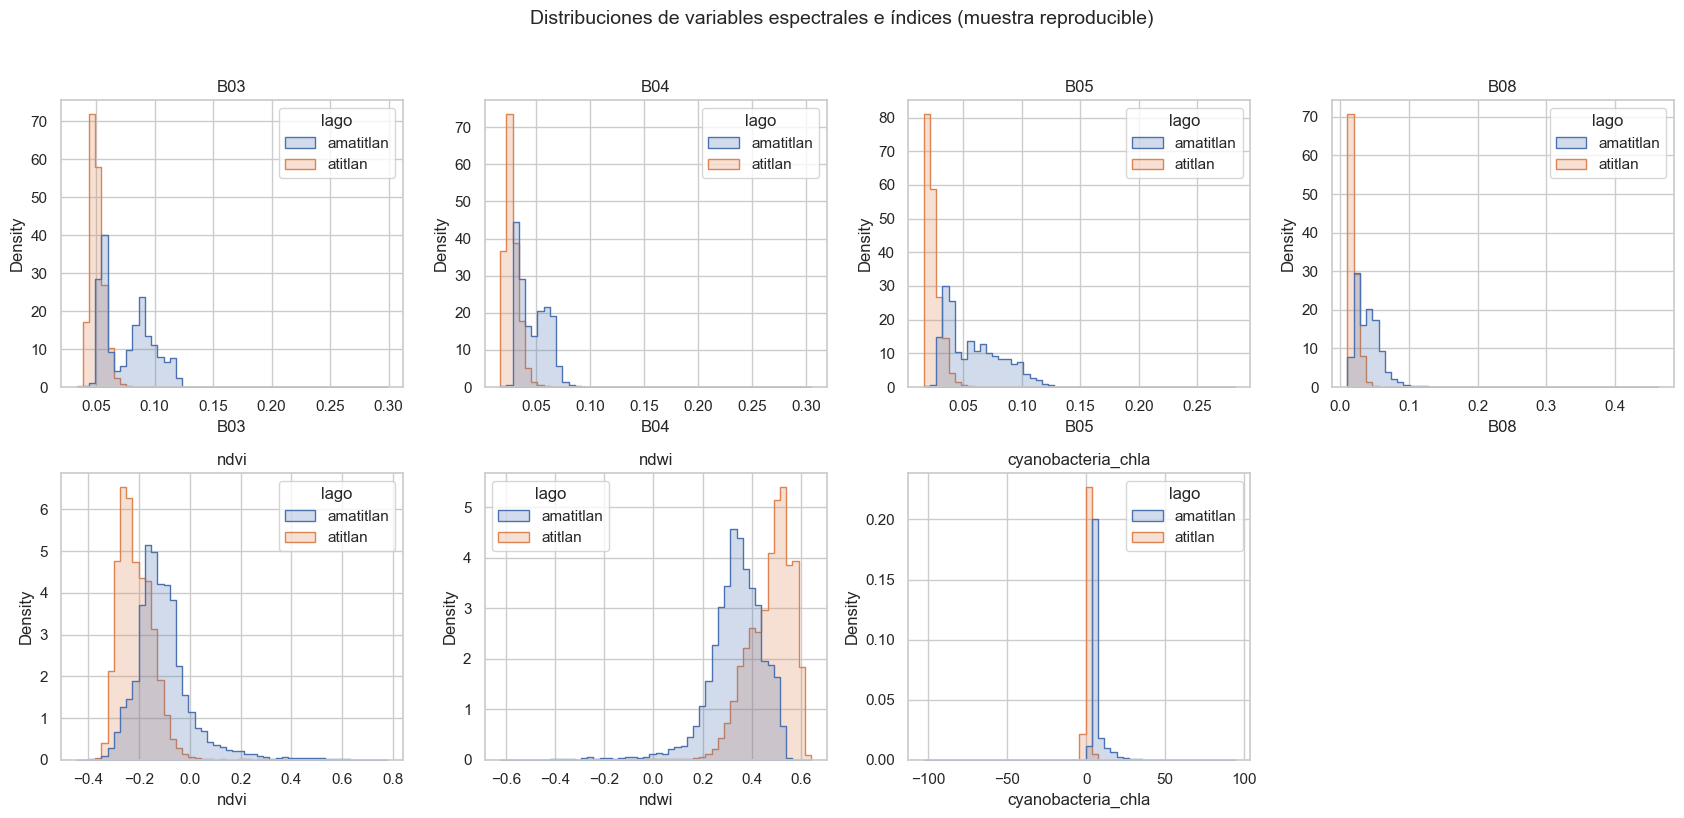

In [7]:
plot_sample = data.sample(n=min(100_000, len(data)), random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for column, axis in zip(numeric_columns, axes.flat):
    sns.histplot(data=plot_sample, x=column, hue="lago", bins=50, element="step", stat="density", common_norm=False, ax=axis)
    axis.set_title(column)
axes.flat[-1].axis("off")
fig.suptitle("Distribuciones de variables espectrales e índices (muestra reproducible)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

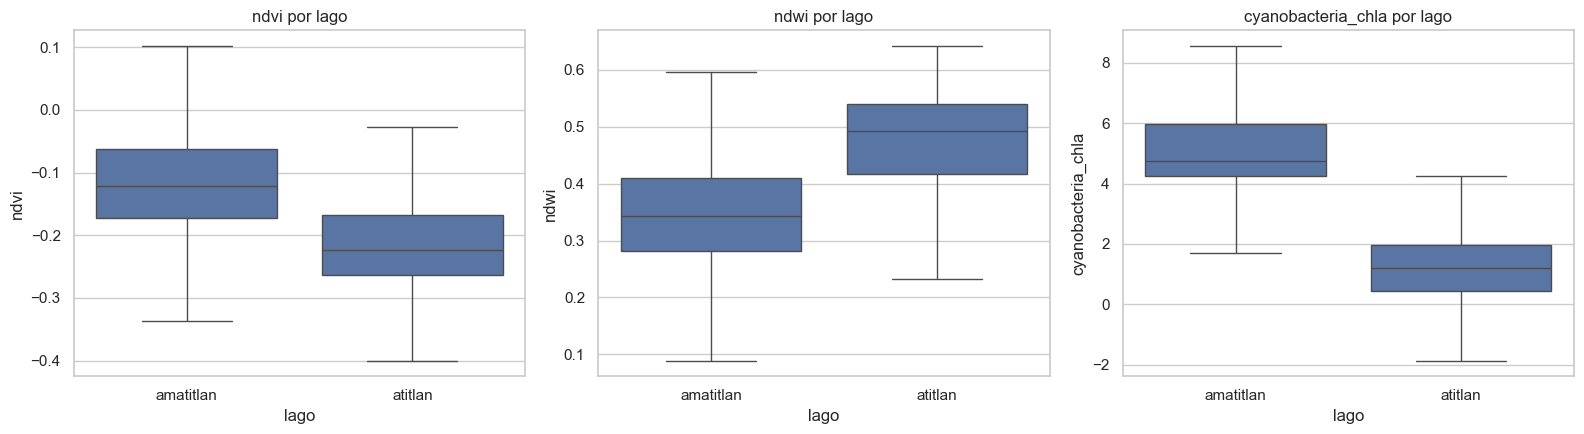

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for column, axis in zip(["ndvi", "ndwi", "cyanobacteria_chla"], axes):
    sns.boxplot(data=plot_sample, x="lago", y=column, showfliers=False, ax=axis)
    axis.set_title(f"{column} por lago")
plt.tight_layout()
plt.show()

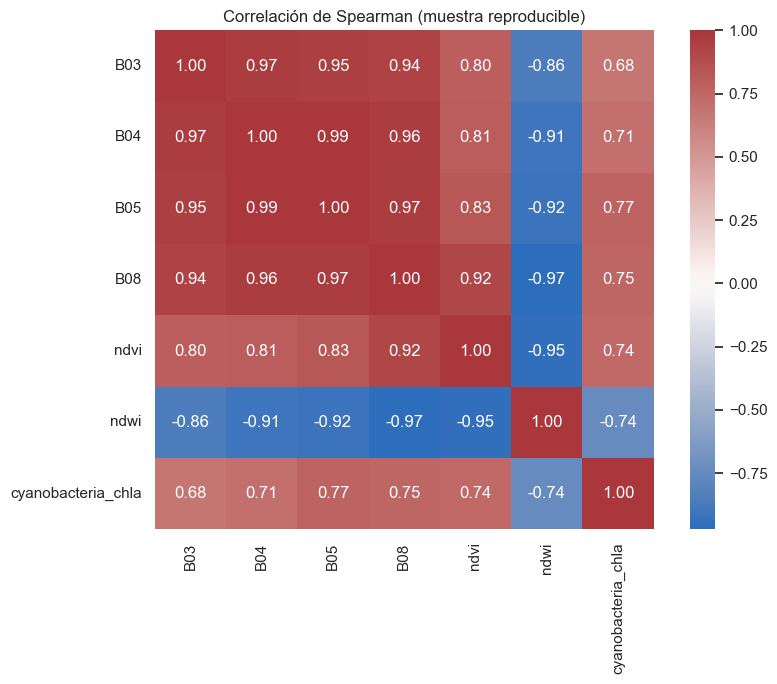

In [9]:
correlation = plot_sample[numeric_columns].corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Correlación de Spearman (muestra reproducible)")
plt.tight_layout()
plt.show()

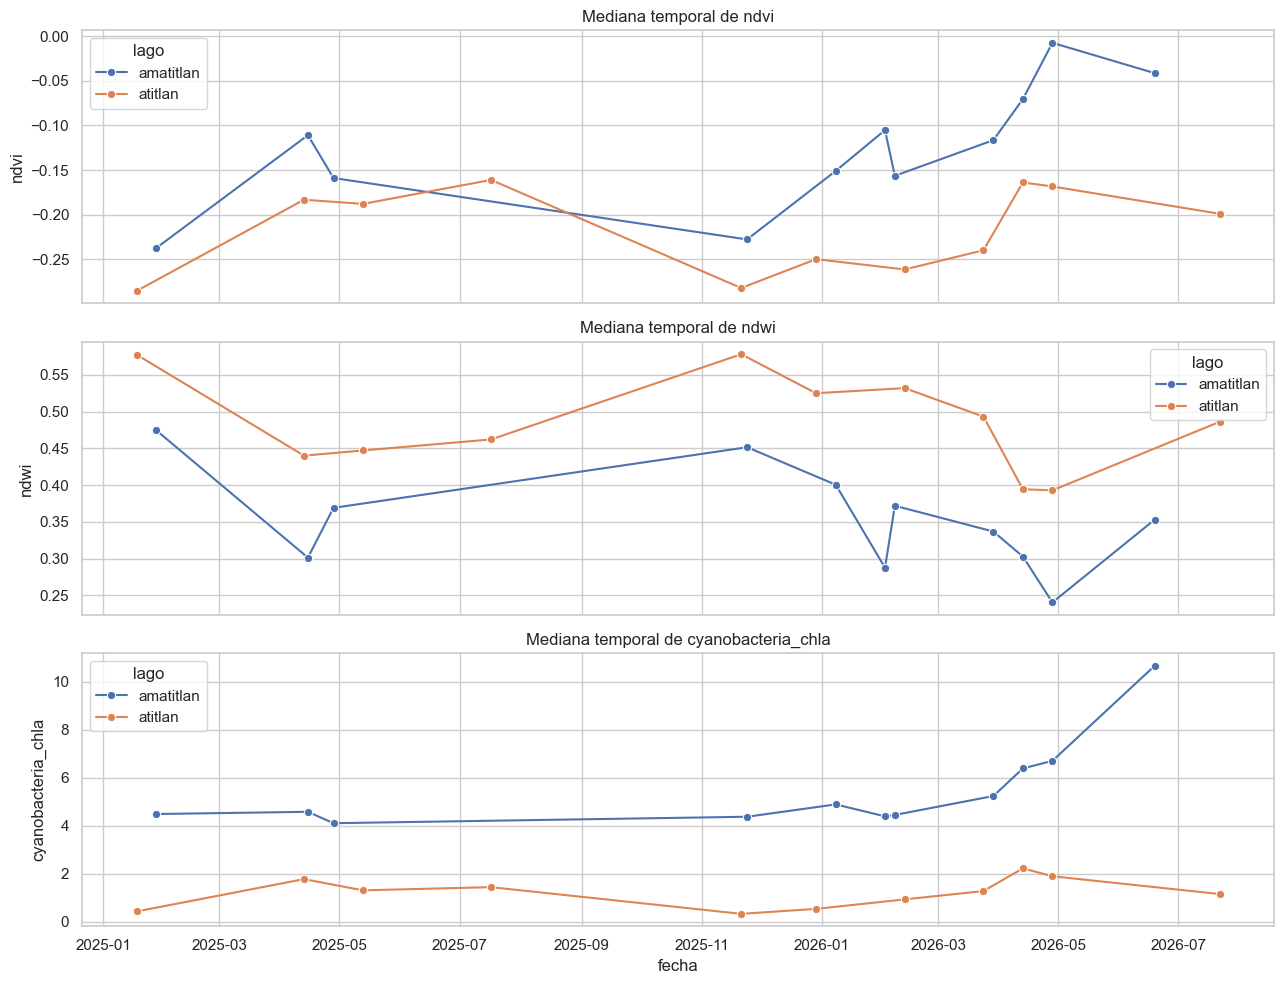

In [10]:
temporal_summary = (
    data.groupby(["lago", "fecha"], observed=True)[["ndvi", "ndwi", "cyanobacteria_chla"]]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for column, axis in zip(["ndvi", "ndwi", "cyanobacteria_chla"], axes):
    sns.lineplot(data=temporal_summary, x="fecha", y=column, hue="lago", marker="o", ax=axis)
    axis.set_title(f"Mediana temporal de {column}")
plt.tight_layout()
plt.show()

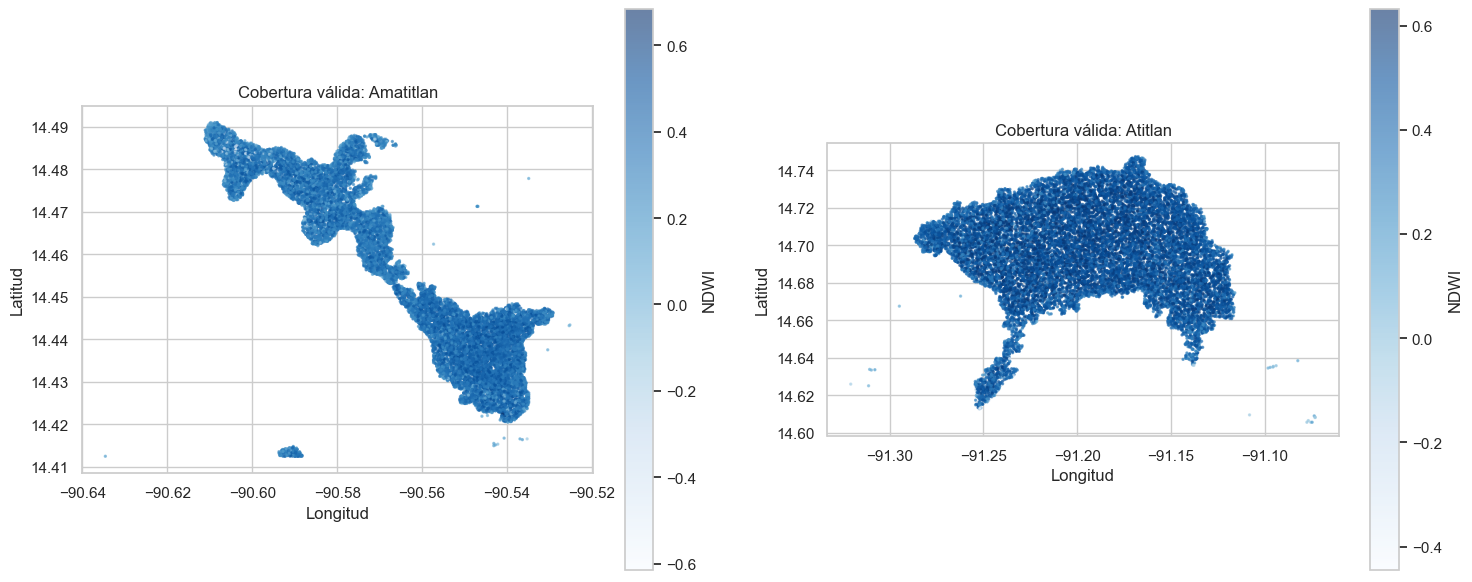

In [11]:
# Mapa de cobertura: máximo 15,000 píxeles por lago para conservar legibilidad.
spatial_sample = (
    data.groupby("lago", observed=True, group_keys=False)
    .apply(lambda group: group.sample(n=min(15_000, len(group)), random_state=42), include_groups=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for lake, axis in zip(data["lago"].cat.categories, axes):
    subset = spatial_sample[spatial_sample["lago"] == lake] if "lago" in spatial_sample else data[data["lago"] == lake].sample(n=min(15_000, (data["lago"] == lake).sum()), random_state=42)
    points = axis.scatter(subset["longitud"], subset["latitud"], c=subset["ndwi"], s=2, cmap="Blues", alpha=0.6)
    axis.set(title=f"Cobertura válida: {lake.title()}", xlabel="Longitud", ylabel="Latitud")
    axis.set_aspect("equal", adjustable="box")
    fig.colorbar(points, ax=axis, label="NDWI")
plt.tight_layout()
plt.show()

### Lectura del análisis exploratorio

- Las tablas permiten comparar centro, dispersión, colas y posibles valores extremos sin depender solamente de las gráficas.
- Los histogramas y diagramas de caja muestran si las distribuciones espectrales cambian entre lagos. Estas diferencias deben considerarse posteriormente al evaluar generalización entre lagos.
- La correlación de Spearman identifica asociaciones monotónicas y posible redundancia entre bandas e índices, pero no implica causalidad.
- Las medianas por fecha permiten detectar variación temporal y escenas atípicas. El número desigual de observaciones por fecha responde principalmente a la máscara de calidad y nubosidad, por lo que no debe interpretarse como un cambio en el área real del lago.
- Los mapas confirman que las coordenadas preservan la forma y cobertura espacial de cada lago. La muestra del mapa se utiliza solo para visualización; el conjunto exportado contiene todos los píxeles válidos.

Las interpretaciones ambientales específicas deben basarse en los valores que aparecen al ejecutar el notebook. No se atribuye automáticamente todo cambio espectral a cianobacterias: turbidez, sedimentos, brillo superficial, atmósfera y nubes residuales también pueden alterar las bandas e índices.

## 5. Exportación reproducible

In [12]:
dataset_path = OUTPUT_DIR / "datos_ml_lagos.csv.gz"
quality_path = OUTPUT_DIR / "reporte_calidad.csv"
schema_path = OUTPUT_DIR / "diccionario_variables.csv"
counts_path = OUTPUT_DIR / "observaciones_por_lago_fecha.csv"

data.to_csv(dataset_path, index=False, compression="gzip", date_format="%Y-%m-%d")
quality_report.to_csv(quality_path, index=False, date_format="%Y-%m-%d")
schema.to_csv(schema_path, index=False)
observations_by_date.to_csv(counts_path, index=False, date_format="%Y-%m-%d")

print("Archivos generados:")
for path in [dataset_path, quality_path, schema_path, counts_path]:
    print(f"- {path.relative_to(ROOT)} ({path.stat().st_size / 1024**2:,.2f} MB)")

Archivos generados:
- resultados\ejercicio_1\datos_ml_lagos.csv.gz (124.99 MB)
- resultados\ejercicio_1\reporte_calidad.csv (0.00 MB)
- resultados\ejercicio_1\diccionario_variables.csv (0.00 MB)
- resultados\ejercicio_1\observaciones_por_lago_fecha.csv (0.00 MB)


## 6. Decisiones y consideraciones finales (1.6)

1. **Unidad de observación:** se eligió el centro de cada píxel válido de la grilla de índices. Se mantienen longitud, latitud, fecha y lago para permitir validaciones espaciales y temporales posteriores.
2. **Alineación espacial:** las bandas y los índices no comparten CRS ni dimensiones. Se reproyectaron las bandas a la grilla de índices, en vez de unir arreglos por posición, lo cual habría asociado mediciones de lugares diferentes.
3. **Límite del lago, nubes y NoData:** se utilizó `valid_mask` de la Parte I como fuente principal de validez. Se complementó con finitud, rangos matemáticos de índices y rangos físicos tolerantes de bandas. No se imputaron píxeles inválidos porque una imputación espacial podría inventar patrones y reducir artificialmente la variabilidad.
4. **Escala espectral:** las bandas se expresaron como reflectancia dividiendo los números digitales entre 10,000, lo que facilita su interpretación y comparación.
5. **Valores extremos:** no se aplicó recorte estadístico por percentiles. Un florecimiento real puede ser extremo; eliminarlo solo por rareza podría borrar la señal de interés. Los filtros aplicados responden a reglas de validez, no a la distribución observada.
6. **Trazabilidad:** se exportan el conjunto completo, el reporte de calidad, el diccionario de variables y los conteos por lago-fecha.
7. **Prevención de fuga de información:** `cyanobacteria_chla` se conserva porque es necesario para construir la respuesta en el Ejercicio 2, pero **no deberá emplearse como predictor**, ni tampoco cualquier transformación directa de este índice. La selección final de predictores deberá revisar además qué bandas intervienen en la fórmula original del índice para evitar fuga indirecta, según lo solicitado en las instrucciones.

El resultado queda listo para construir la respuesta binaria, seleccionar predictores y definir divisiones de entrenamiento que respeten la dependencia espacial y temporal.